In [16]:
import numpy as np
import pandas as pd

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [19]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## EDA

In [20]:
df.info

<bound method DataFrame.info of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban 

In [21]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## We Will Drop ID Column  

In [22]:
df.drop(columns=["id"], inplace= True)

## Handling The Missing Values Present in BMI

In [23]:
df['bmi'].fillna(df['bmi'].median(), inplace =True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_11632\38078317.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace =True)


In [24]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,Unknown,1
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## Now We Will Convert the Text Value to Numbers

In [25]:
df= pd.get_dummies(df, drop_first = True)

In [26]:
df.head(5)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False


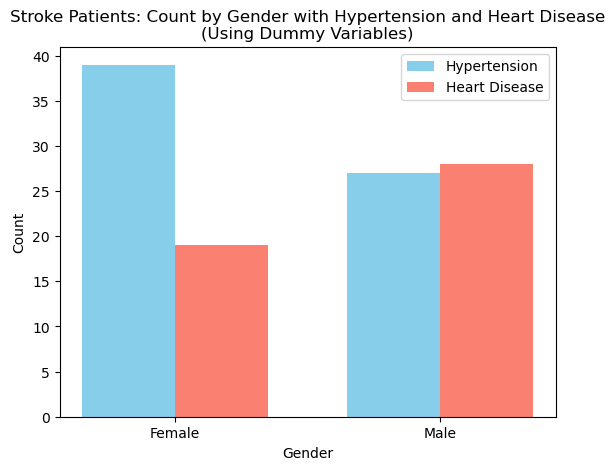

In [28]:
# Convert categorical to dummies with drop_first=True (Female dropped)
df = pd.get_dummies(df, drop_first=True)

# Count stroke patients with hypertension by gender dummies
stroke_hypertension_female = df[(df['stroke'] == 1) & (df['hypertension'] == 1) & (df.get('gender_Male', 0) == 0)].shape[0]
stroke_hypertension_male = df[(df['stroke'] == 1) & (df['hypertension'] == 1) & (df['gender_Male'] == 1)].shape[0]

# Count stroke patients with heart disease by gender dummies
stroke_heart_disease_female = df[(df['stroke'] == 1) & (df['heart_disease'] == 1) & (df.get('gender_Male', 0) == 0)].shape[0]
stroke_heart_disease_male = df[(df['stroke'] == 1) & (df['heart_disease'] == 1) & (df['gender_Male'] == 1)].shape[0]

# Prepare data for plotting
labels = ['Female', 'Male']
hypertension_counts = [stroke_hypertension_female, stroke_hypertension_male]
heart_disease_counts = [stroke_heart_disease_female, stroke_heart_disease_male]

x = range(len(labels))  # Positions on X-axis

# Plotting
fig, ax = plt.subplots()
bar_width = 0.35

bars1 = ax.bar(x, hypertension_counts, width=bar_width, label='Hypertension', color='skyblue')
bars2 = ax.bar([i + bar_width for i in x], heart_disease_counts, width=bar_width, label='Heart Disease', color='salmon')

ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_title('Stroke Patients: Count by Gender with Hypertension and Heart Disease\n(Using Dummy Variables)')
ax.set_xticks([i + bar_width / 2 for i in x])
ax.set_xticklabels(labels)
ax.legend()

plt.show()

# Split Features & Target

In [29]:
x= df.drop("stroke",axis=1)
y=df["stroke"]

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)